In [8]:
# Numerical libraries
import numpy as np   

from sklearn.model_selection import train_test_split

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

# to handle data in form of rows and columns 
import pandas as pd    

# importing ploting libraries
import matplotlib.pyplot as plt   

#importing seaborn for statistical plots
import seaborn as sns
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from scipy.stats import zscore

Q: 1: 
Use a new Python notebook and read the data set. Data pre-processing - 
Understand the data and treat missing values (Use box plot), outliers (5 points)

In [9]:
# reading the CSV file into pandas dataframe
vehicle = pd.read_csv("vehicle.csv")  

In [10]:
vehicle.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [11]:
vehicle.shape

(846, 19)

In [12]:
vehicle.dtypes

compactness                      int64
circularity                    float64
distance_circularity           float64
radius_ratio                   float64
pr.axis_aspect_ratio           float64
max.length_aspect_ratio          int64
scatter_ratio                  float64
elongatedness                  float64
pr.axis_rectangularity         float64
max.length_rectangularity        int64
scaled_variance                float64
scaled_variance.1              float64
scaled_radius_of_gyration      float64
scaled_radius_of_gyration.1    float64
skewness_about                 float64
skewness_about.1               float64
skewness_about.2               float64
hollows_ratio                    int64
class                           object
dtype: object

In [13]:
vehicle.describe().transpose()  

,count,mean,std,min,25%,50%,75%,max
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.0,119.0
circularity,841.0,44.828775,6.152172,33.0,40.00,44.0,49.0,59.0
distance_circularity,842.0,82.110451,15.778292,40.0,70.00,80.0,98.0,112.0
radius_ratio,840.0,168.888095,33.520198,104.0,141.00,167.0,195.0,333.0
pr.axis_aspect_ratio,844.0,61.678910,7.891463,47.0,57.00,61.0,65.0,138.0
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.0,55.0
scatter_ratio,845.0,168.901775,33.214848,112.0,147.00,157.0,198.0,265.0
elongatedness,845.0,40.933728,7.816186,26.0,33.00,43.0,46.0,61.0
pr.axis_rectangularity,843.0,20.582444,2.592933,17.0,19.00,20.0,23.0,29.0
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.0,188.0


In [14]:
vehicle.isnull().any()

compactness                    False
circularity                     True
distance_circularity            True
radius_ratio                    True
pr.axis_aspect_ratio            True
max.length_aspect_ratio        False
scatter_ratio                   True
elongatedness                   True
pr.axis_rectangularity          True
max.length_rectangularity      False
scaled_variance                 True
scaled_variance.1               True
scaled_radius_of_gyration       True
scaled_radius_of_gyration.1     True
skewness_about                  True
skewness_about.1                True
skewness_about.2                True
hollows_ratio                  False
class                          False
dtype: bool

In [19]:
def find_cols_with_missing_values():
    count = 0
    for col in vehicle.columns:
        if (vehicle[col].isnull().sum()):
            count += 1
            print ("Column {} has {} missing values".format(col, vehicle[col].isnull().sum()))
    if (count == 0):
        print ("There are no missing values")

In [21]:
find_cols_with_missing_values()
# Replace missing values with median
vehicle.fillna(vehicle.median(), inplace=True)

Column circularity has 5 missing values
Column distance_circularity has 4 missing values
Column radius_ratio has 6 missing values
Column pr.axis_aspect_ratio has 2 missing values
Column scatter_ratio has 1 missing values
Column elongatedness has 1 missing values
Column pr.axis_rectangularity has 3 missing values
Column scaled_variance has 3 missing values
Column scaled_variance.1 has 2 missing values
Column scaled_radius_of_gyration has 2 missing values
Column scaled_radius_of_gyration.1 has 4 missing values
Column skewness_about has 6 missing values
Column skewness_about.1 has 1 missing values
Column skewness_about.2 has 1 missing values


In [22]:
num_of_outliers = 0
def find_and_treat_outliers (col):
    global num_of_outliers
    q1 = np.percentile(vehicle[col],25)
    q3 = np.percentile(vehicle[col],75)
    iqr = q3 - q1
    median = np.percentile(vehicle[col],50)
    out_min = np.subtract(q1,(1.5*iqr))
    out_max = np.add(q3,(1.5*iqr))
    outlier_present = 0;
    for rows in range(1,len(vehicle)):
        if (vehicle[col].loc[rows] < out_min):
            vehicle[col].loc[rows] = q1
            num_of_outliers += 1
        elif (vehicle[col].loc[rows] > out_max):
            vehicle[col].loc[rows] = q3
            num_of_outliers += 1

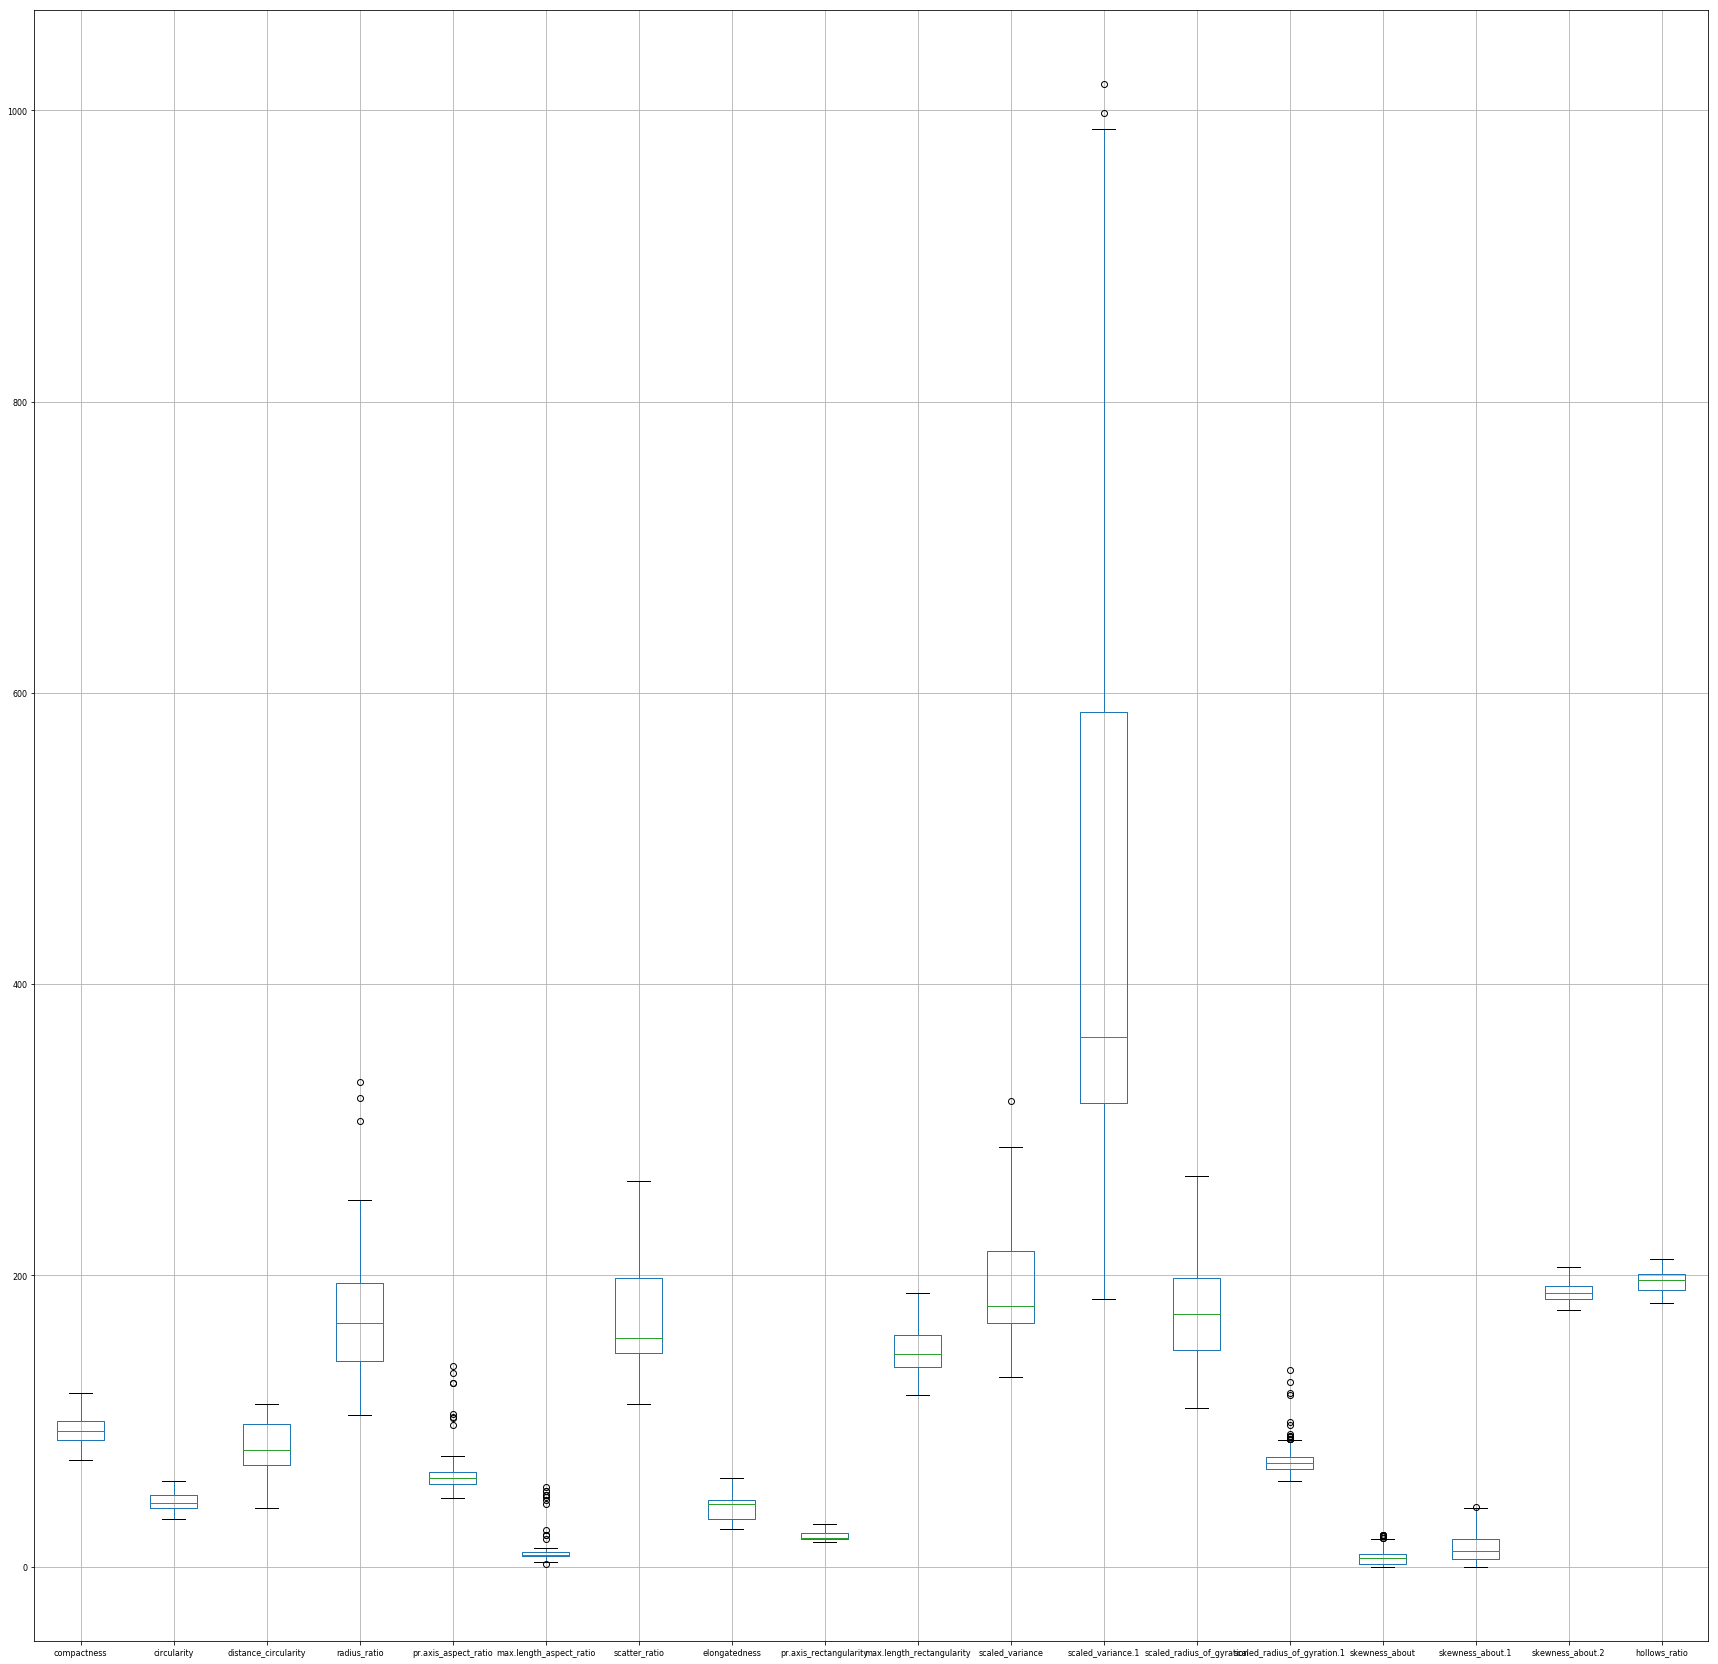

In [23]:
vehicle.boxplot(figsize=(30,30), fontsize=8)
plt.show()

In [24]:
for cols in vehicle.columns:
    if (cols != 'class'):
        find_and_treat_outliers(cols)

In [56]:
print (num_of_outliers)

55


Q:2: Understanding the attributes - Find relationship between different attributes (Independent variables) and choose 
carefully which all attributes have to be a part of the analysis and why (5 points)

In [57]:
# Finding correlated independent variables and removing those which has minimum correlation with the target variable
def perfect_correlated_columns (threshold):
    cols_to_retain = ['class']
    corr_mat = vehicle.corr()
    corr_mat = np.abs(corr_mat)
    for col in corr_mat.columns:
        perfect_corr = corr_mat[col][corr_mat[col] > threshold].index.tolist()
        max_corr = 0
        for attr in perfect_corr:
            if (np.abs(vehicle[attr].corr(vehicle['class'])) > max_corr):
                max_corr = np.abs(vehicle[attr].corr(vehicle['class']))
                max_col = attr
        if (max_col not in cols_to_retain):
            cols_to_retain.append(max_col)
    return cols_to_retain

In [58]:
from sklearn.preprocessing import LabelEncoder

In [59]:
#Encoding class variable to numeric
labelencoder = LabelEncoder()
vehicle['class'] = labelencoder.fit_transform(vehicle['class'])

In [60]:
# Drop columns which have absolute correlation less than 0.1

for cols in vehicle.columns:
    if (np.abs(vehicle[cols].corr(vehicle['class'])) < 0.1):
        vehicle.drop(cols, axis=1,inplace=True)

Q: 3: Use PCA from scikit learn and elbow plot to find out reduced number of dimension 
      (which covers more than 95% of the variance) - 10 points

In [61]:
# Function for PCA

def pca ():
    X = vehicle.drop('class',axis=1)
    y = vehicle['class']
    std_scale = StandardScaler()
    X_std = std_scale.fit_transform(X)

    cov_matrix = np.cov(X_std.T)
    eig_vals,eig_vecs = np.linalg.eig(cov_matrix)
    idx = np.argsort(eig_vals)
    eig_vals = eig_vals[idx]
    eig_vecs = eig_vecs[idx]
    eig_vals =np.flip(eig_vals,axis=0)
    eig_vecs = np.flip(eig_vecs,axis=0)


    variance_explained = (eig_vals/np.sum(eig_vals))*100
    var_cols = range(1,cov_matrix.shape[1]+1)
    plt.plot(var_cols,variance_explained)
    plt.show()
    
    total_var = 0
    n_comp = 0
    
    # Choosing the number number of components with 95% variance
    for var in variance_explained:
        total_var += var
        if (total_var <= 95):
            n_comp += 1
        else:
            break;
    print ("Number of components {}".format(n_comp))
    X_reduced = PCA(n_components=n_comp).fit_transform(X_std)
    return X_reduced

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

In [63]:
X = vehicle.drop(labels= "class" , axis = 1)
y = vehicle[["class"]]

Q: 4: Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) 
      and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)

In [64]:
# Function for GrindSearch

#X_train,x_test,Y_train,y_test

def grid_search(X_reduced):
    X_train,x_test,y_train,y_test = train_test_split (X_reduced,y,test_size=0.30,random_state=1)


    parameters = {'kernel':('linear', 'rbf'), 'C':[0.01, 0.05, 0.5, 1]}
    svc = svm.SVC()
    clf = GridSearchCV(svc, parameters)
    clf.fit(X_train,y_train)
    print(clf.best_params_)
    return clf.best_params_

In [65]:
def supportvm(X_reduced):
    best_params = grid_search(X_reduced)
    model = svm.SVC(C=best_params['C'], kernel=best_params['kernel'])
    model.fit(X_train, y_train)
    # check the accuracy on the training set
    print("==============Model score on the training set=====================")
    print(model.score(X_train, y_train))
    y_pred = model.predict(x_test)
    print ("================Classification report==============================")
    print(classification_report(y_pred, y_test))
    print("=================Confusion matrix==================================")
    print(confusion_matrix(y_pred, y_test))
    print("==================Accuracy score===================================")
    print(accuracy_score(y_pred,y_test))
    return best_params

In [70]:
X_train,x_test,y_train,y_test = train_test_split (X_reduced,y,test_size=0.30,random_state=1)

def kcross_val (splits,c,kernel_type):
    acc_scores = []
    kf = KFold(n_splits=splits)
    for train, test in kf.split(X,y):
        X_train, X_test, y_train, y_test = np.array(X_reduced)[train], np.array(X_reduced)[test], np.array(y)[train],np.array(y)[test]
        model= svm.SVC(C=c,kernel=kernel_type)
       	model.fit(X_train,y_train)       
        y_pred = model.predict(X_test)
        acc_scores.append(accuracy_score(y_pred,y_test))
    return acc_scores

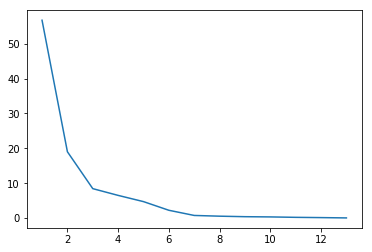

Number of components 4
(846, 4)
{'C': 1, 'kernel': 'rbf'}
==============Model score on the training set=====================
0.8716216216216216
================Classification report==============================
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        60
           1       0.80      0.85      0.82       125
           2       0.74      0.67      0.70        69

   micro avg       0.81      0.81      0.81       254
   macro avg       0.81      0.80      0.80       254
weighted avg       0.81      0.81      0.81       254

=================Confusion matrix==================================
[[ 53   5   2]
 [  5 106  14]
 [  1  22  46]]
==================Accuracy score===================================
0.8070866141732284
================= K-Fold accuracy scores =====================
0.8062184873949579


In [71]:
X_reduced = pca()

print(X_reduced.shape)
best_params = supportvm(X_reduced)
acc_scores = kcross_val(10,best_params['C'],best_params['kernel'])
print ("================= K-Fold accuracy scores =====================")
print (np.mean(acc_scores))

In [75]:
# Removing independent variables which have an absolute correlation > 0.8
cols_to_retain = perfect_correlated_columns(0.8)
for cols in vehicle.columns:
    if (cols not in cols_to_retain):
        vehicle.drop(cols, axis = 1,inplace=True)

In [76]:
print(cols_to_retain)

['class', 'elongatedness', 'max.length_aspect_ratio', 'scaled_radius_of_gyration.1', 'skewness_about']


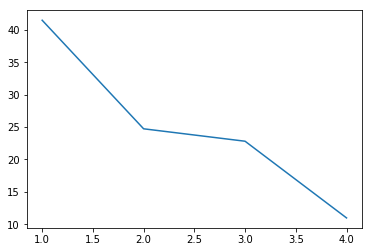

Number of components 3
(846, 3)
{'C': 1, 'kernel': 'rbf'}
==============Model score on the training set=====================
0.8716216216216216
================Classification report==============================
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        60
           1       0.80      0.85      0.82       125
           2       0.74      0.67      0.70        69

   micro avg       0.81      0.81      0.81       254
   macro avg       0.81      0.80      0.80       254
weighted avg       0.81      0.81      0.81       254

=================Confusion matrix==================================
[[ 53   5   2]
 [  5 106  14]
 [  1  22  46]]
==================Accuracy score===================================
0.8070866141732284
================= K-Fold accuracy scores =====================
0.7067927170868348


In [77]:
X_reduced = pca()

print(X_reduced.shape)
best_params = supportvm(X_reduced)
acc_scores = kcross_val(10,best_params['C'],best_params['kernel'])
print ("================= K-Fold accuracy scores =====================")
print (np.mean(acc_scores))